# ПЗ-1. Генерация текста с использованием RNN/LSTM

В этой практической работе рассмотрим полный пайплайн генерации текста с помощью нейронных сетей.

На примере новостных текстов последовательно пройдем основные этапы работы с языковой моделью:

* подготовка и очистка текстового корпуса;
* токенизация текста разными способами;
* формирование обучающих последовательностей;
* создание моделей `Dense`, `RNN` и `LSTM`;
* обучение моделей и отслеживание экспериментов с помощью MLflow;
* оценка качества по `loss` и `perplexity`;
* генерация продолжения текста по заданному prompt;
* сравнение результатов разных токенизаторов и архитектур.

Главная цель практики - познакомиться не с отдельной моделью, а с **полным циклом построения эксперимента по генерации текста**: от исходного корпуса до обучения, оценки и анализа результатов.


## 0. Установка зависимостей и импорты

In [171]:
#!pip install -q datasets mlflow 

In [22]:
import re, random
from collections import Counter
import gc
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import mlflow
import os
import os
import math
import torch
import torch.nn.functional as F
import mlflow
import math
import pickle
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.trainers import BpeTrainer
from datasets import load_dataset
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Настройка MLflow

Перед обучением настроим MLflow для хранения и отслеживания экспериментов.
Сейчас результаты сохраняются **локально** в `mlflow.db`. В реальном проекте MLflow можно подключить к удаленному хранилищу или серверу. Тогда результаты экспериментов будут доступны с разных компьютеров.
В данном случае все данные MLflow сохраняются в локальной базе mlflow.db. Это удобно для практической работы: базу можно скопировать на другой компьютер и продолжить работать с сохраненными экспериментами.

Например, можно перенести mlflow.db на другую машину и подключить.

С помощью MLflow мы сможем:

* сравнивать разные запуски обучения;
* анализировать параметры и метрики моделей;
* сохранять артефакты, например веса лучшей модели;
* выгружать результаты экспериментов для дальнейшего анализа.



In [2]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("pz1_text_generation")

2026/09/17 09:58:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/17 09:58:15 INFO mlflow.store.db.utils: Updating database tables
2026/09/17 09:58:34 INFO mlflow.tracking.fluent: Experiment with name 'pz1_text_generation' does not exist. Creating a new experiment.


<Experiment: artifact_location='/media/project/susu_course/neural_gen/practices/mlruns/1', creation_time=1789639114050, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789639114050, lifecycle_stage='active', name='pz1_text_generation', tags={}, trace_location=None, workspace='default'>

## 1. Подготовка данных

В работе используется набор данных `IlyaGusev/gazeta`, содержащий русскоязычные новостные статьи с сайта «Газета.Ru». 
Изначально набор данных предназначен для задачи автоматического реферирования: для каждой новости представлены полный текст статьи и ее краткое изложение.

Для нашей задачи важна именно **полная версия новостных статей**. Эти тексты образуют корпус, на котором модель будет изучать закономерности русского языка и впоследствии генерировать новые последовательности текста.

Корпус состоит из новостей на различные темы и содержит большое количество естественных примеров русского языка. Благодаря этому модель может обучаться на реальных словах, их сочетаниях, предложениях и характерных для новостных текстов языковых конструкциях.

В работе количество используемых статей ограничивается параметром:

```python
RAW_ARTICLES_LIMIT = 10000
```
Если вычислительные ресурсы позволяют, рекомендуется увеличить это значение. Использование большего количества статей дает модели больше разнообразных примеров для обучения и может положительно повлиять на качество и разнообразие генерируемого текста.

In [3]:

RAW_ARTICLES_LIMIT = 1000

ds = load_dataset("IlyaGusev/gazeta", split="train", streaming=True)
texts = []
for i, row in enumerate(ds):
    if i >= RAW_ARTICLES_LIMIT:
        break
    texts.append(row["text"])

print(f"Загружено статей: {len(texts)}")
print(texts[0][:300])
len(" ".join(texts).split())


Загружено статей: 1000
Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Также ставку налога могут корректировать региональные власти: согласно Налоговому кодексу, базовый тариф, установленный правительством, может быть уменьшен в пять 


573912

## Очистка текстов

Перед обучением модели исходные статьи необходимо привести к более однородному виду. 
В текстах могут встречаться HTML-теги, специальные HTML-последовательности, лишние пробелы и переносы строк. 
Кроме того, для упрощения последующей обработки из текста удаляются знаки пунктуации, чтобы они не становились дополнительными токенами и не увеличивали сложность задачи для относительно простых моделей.
Для этого используется функция `clean_text`

In [4]:
def clean_text(text: str) -> str:
    """
    Очищает текст новостной статьи от HTML-разметки,
    лишних пробелов и знаков пунктуации.

    Args:
        text: Исходный текст статьи.

    Returns:
        Очищенный текст.
    """
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"[\r\t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r" {2,}", " ", text)
    for tok in ', ! ? : ; — – ( ) [ ] { } « » "'.split():
        text = text.replace(tok, '')
    return text.strip()


texts = [clean_text(t) for t in texts]

## Разделение корпуса

После очистки корпуса разделяем статьи на обучающую, валидационную и тестовую выборки.

Важно, что в данном случае мы делим данные **по документам, а не по отдельным предложениям**. 
Одна новостная статья представляет собой связный текст и содержит повторяющиеся слова, темы и языковые конструкции. 
Если разделять предложения случайным образом, предложения из одной и той же статьи могут попасть одновременно в `train`, `val` и `test`. 
В результате модель при проверке может встретить знакомые ей фрагменты текста, и оценка качества будет менее показательной.


In [5]:
# Поэтому сначала перемешиваем целые статьи
random.shuffle(texts)

#А затем распределяем документы между тремя выборками
n = len(texts)
n_train = int(n * 0.5)
n_val = int(n * 0.25)
train_docs = texts[:n_train]
val_docs = texts[n_train:n_train + n_val]
test_docs = texts[n_train + n_val:]
print(f"train={len(train_docs)}  val={len(val_docs)}  test={len(test_docs)}")


train=500  val=250  test=250


## 2. Токенизация

Перед подачей текста в модель его необходимо преобразовать в последовательность токенов.
В работе мы сравним несколько различных подходов к токенизации и посмотрим, как выбранный токенизатор влияет на размер словаря, длину последовательностей и последующее обучение модели.
Чтобы разные токенизаторы имели единый интерфейс и их было удобно использовать в одном коде, введем общий базовый класс `BaseTokenizer`
Базовый класс задает общий набор операций, которые должен поддерживать каждый используемый токенизатор.


In [6]:
class BaseTokenizer:
    """Базовый интерфейс токенизатора для работы с текстовыми данными."""

    pad_id = 0

    def encode(self, text: str) -> list[int]:
        """Преобразует текст в последовательность идентификаторов токенов.

        Args:
            text: Исходный текст для токенизации.

        Returns:
            Последовательность идентификаторов токенов.

        """
        raise NotImplementedError

    def decode(self, ids: list[int]) -> str:
        """Восстанавливает текст из последовательности идентификаторов.

        Args:
            ids: Последовательность идентификаторов токенов.

        Returns:
            Восстановленный текст.

        """
        raise NotImplementedError

    @property
    def vocab_size(self) -> int:
        """Возвращает размер словаря токенизатора.

        Returns:
            Количество токенов в словаре.
        """
        raise NotImplementedError

    def get_token_count(self, text: str) -> int:
        """Возвращает количество токенов в переданном тексте.

        Args:
            text: Исходный текст.

        Returns:
            Количество токенов.
        """
        return len(self.encode(text))

## Символьный токенизатор

Первым рассмотрим самый простой вариант токенизации: посимвольный `CharTokenizer`.
В этом подходе каждый отдельный символ текста рассматривается как самостоятельный токен.
Сначала на основе всех текстов корпуса формируется множество уникальных символов. 
Затем каждому символу сопоставляется свой числовой идентификатор.


### Специальные токены
Специальные токены - это служебные элементы словаря, которые не являются обычными символами текста.
Они нужны, чтобы передавать модели дополнительную информацию о структуре последовательности: где находятся пустые позиции, какой символ неизвестен токенизатору и где заканчивается текст.
В данном токенизаторе используются три специальных токена: `<pad>`, `<unk>` и `<eos>`.
`<pad>` используется для выравнивания последовательностей разной длины.
Например, если одна последовательность содержит 5 токенов, а другая 8, их можно привести к общей длине:
```text
а б в г д <pad> <pad> <pad>
а б в г д е ж з
```
`<unk>` - неизвестный токен
Он используется, если во входном тексте встречается символ или слово, которого нет в словаре токенизатора.
Такой символ заменяется на <unk>, чтобы модель могла продолжить обработку последовательности.

`<eos>` конец последовательности
<eos> означает end of sequence, он позволяет явно обозначить границу текста.
при генерации такой токен может использоваться как сигнал о том, что последовательность следует завершить.

In [7]:
class CharTokenizer(BaseTokenizer):
    def __init__(self, docs):
        chars = sorted(set("".join(docs)))
        vocab = ["<pad>", "<unk>", "<eos>"] + chars
        self.stoi = {ch: i for i, ch in enumerate(vocab)}
        self.itos = {i: ch for ch, i in self.stoi.items()}
        self.pad_id = self.stoi["<pad>"]
        self.unk_id = self.stoi["<unk>"]
        self.eos_id = self.stoi["<eos>"]

    @property
    def vocab_size(self):
        return len(self.stoi)

    def encode(self, text):
        return [self.stoi.get(ch, self.pad_id) for ch in text]

    def decode(self, ids):
        return "".join(self.itos.get(i, "") for i in ids)

# Задание 1
Первое задание: по аналогии с `CharTokenizer` реализовать токенизатор `WordTokenizer`.

В отличие от `CharTokenizer`, где каждый символ текста является отдельным токеном, `WordTokenizer` должен рассматривать слова как токены.

Необходимо самостоятельно реализовать класс `WordTokenizer`, сохранив тот же интерфейс, что и у базового токенизатора.

При этом необходимо учитывать ограничение на размер словаря . 
Если в корпусе встречается слишком много разных слов, в словарь следует включать только наиболее часто встречающиеся слова.
Остальные слова при токенизации должны рассматриваться как неизвестные и заменяться на `<unk>`.


In [8]:
class WordTokenizer(BaseTokenizer):
    def __init__(self, docs, max_size=20000):
        # TODO: 
        # TODO:
        # TODO:
        # TODO: 
        pass

    @property
    def vocab_size(self):
        # TODO: 
        pass

    def encode(self, text):
        # TODO: 
        pass
    def decode(self, ids):
        # TODO:
        pass

Следующий вариант - BPE (Byte Pair Encoding). 

В отличие от CharTokenizer и WordTokenizer, BPE разбивает текст на части слов, что позволяет работать и с часто встречающимися словами, и с редкими словами через их известные части

```
машина → маш + ина
машинка → маш + инка

работает → работ + ает
работал → работ + ал ```

In [ ]:
class BPETokenizer(BaseTokenizer):
    def __init__(self, docs, vocab_size=16000):
        self.tokenizer = Tokenizer(BPE(unk_token="<unk>"))
        self.tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
        self.tokenizer.decoder = ByteLevelDecoder()


        trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=["<pad>", "<unk>", "<eos>", ])
        self.tokenizer.train_from_iterator(docs, trainer=trainer)

        self.stoi = self.tokenizer.get_vocab()
        self.itos = {idx: token for token, idx in self.stoi.items()}

        self.pad_id = self.stoi["<pad>"]
        self.unk_id = self.stoi["<unk>"]
        self.eos_id = self.stoi["<eos>"]

    @property
    def vocab_size(self):
        return self.tokenizer.get_vocab_size()

    def encode(self, text):
        return self.tokenizer.encode(text).ids

    def decode(self, ids):
        return self.tokenizer.decode(ids)

    def tokenize(self, text):
        return self.tokenizer.encode(text).tokens

In [10]:
char_tokenizer = CharTokenizer(train_docs)
word_tokenizer = WordTokenizer(train_docs, max_size=50000)
bre_tokenizer = BPETokenizer(train_docs, vocab_size=8000)
TOKENIZER = {'bre': bre_tokenizer, 'char': char_tokenizer, 'word': word_tokenizer}


Сравним токенизаторы по размеру словаря и доле неизвестных токенов `<unk>`


In [11]:
print("Char vocab size:", char_tokenizer.vocab_size)
print("Word vocab size:", word_tokenizer.vocab_size)


def unk_rate(text, tokenizer):
    ids = tokenizer.encode(text)
    return sum(i == tokenizer.unk_id for i in ids) / len(ids)


print(f"[bre] Доля <unk> в train: {unk_rate(' '.join(train_docs[:1000]), bre_tokenizer):.1%}")
print(f"[word] Доля <unk> в train: {unk_rate(' '.join(train_docs[:1000]), word_tokenizer):.1%}")


Char vocab size: 147
Word vocab size: 50000
[bre] Доля <unk> в train: 0.0%
[word] Доля <unk> в train: 0.1%


Для WordTokenizer словарь значительно больше, но 6.5% слов становятся <unk>.
Для нейронной сети это важно: вместо реального слова модель получает одинаковый токен <unk> для разных неизвестных слов. В результате она теряет информацию о них, что может ухудшить обучение и качество генерации текста.

Посмотрим на распределение слов в обучающей выборке.

In [12]:
from razdel import tokenize as razdel_tokenize


def word_tokenize(text):
    return [tok.text.lower() for tok in razdel_tokenize(text)]

print("vocab size:", word_tokenizer.vocab_size)

counter = Counter()

for doc in train_docs:
    counter.update(word_tokenize(doc))

print("unique words:", len(counter))

print("\nMost common:")
for word, count in counter.most_common(5):
    print(repr(word), count)

print("\nRare:")
print(sum(c == 1 for c in counter.values()))
print(sum(c <= 5 for c in counter.values()))

vocab size: 50000
unique words: 50339

Most common:
'.' 17757
'в' 11980
'и' 7021
'на' 5284
'не' 3957

Rare:
27445
43448


!Для корпаса в 20к статей

В корпусе найдено около 250 тыс. уникальных слов, но словарь ограничен 50 тыс. Поэтому в него попадают наиболее часто встречающиеся слова.
При этом около 117 тыс. слов встречаются только один раз, а около 198 тыс. не более пяти раз.
Значительная часть слов является редкой и не попадает в словарь, что и приводит к появлению <unk> при обработке текста.

In [13]:
print("Примеры редких слов:")

rare_words = [word for word, count in counter.items() if count == 1]

for word in rare_words[100:110]:
    print(repr(word))

Примеры редких слов:
'льется'
'потребуются'
'расхлебывание'
'разлившейся'
'переживала'
'проложила'
'соединенных'
'явная'
'нехватка'
'взвинченности'


Проблема не только в том, что это редкие слова. Среди них могут быть важные для конкретного контекста слова: фамилии, имена, названия организаций, географические названия и другие детали.
При ограниченном словаре такие слова заменяются на `<unk>`, из-за чего модель теряет часть информации о содержании текста. Для генерации это может приводить к потере конкретики и ухудшению связности текста.

## Задание 2: подготовка данных

Языковая модель обучается предсказывать **следующий токен по предыдущим токенам**. При этом предсказание выполняется на каждом шаге последовательности.

Например, для текста:

```text
я люблю читать книги
```

обучающая пара выглядит так:

```text
Input:  я      люблю   читать
Target: люблю  читать  книги
```

Таким образом, модель учится:

* по `я` предсказывать `люблю`;
* по `я люблю` предсказывать `читать`;
* по `я люблю читать` предсказывать `книги`.

Для создания большого количества таких примеров используется **скользящее окно**.

### Задание

Необходимо реализовать класс `SlidingWindowDataset`, который:

* преобразует документы в последовательности токенов;
* формирует последовательности фиксированной длины `seq_len`;
* создает `input` и `target`, сдвигая `target` на один токен относительно `input`;
* использует параметр `stride` для управления шагом скользящего окна;
* добавляет разделитель между статьями.


In [14]:
class SlidingWindowDataset(Dataset):
    """Формирует обучающие пары из текста с помощью скользящего окна.

    Args:
        docs: Список текстовых документов.
        tokenizer: Токенизатор для преобразования текста в идентификаторы.
        seq_len: Длина входной последовательности.
        stride: Шаг перемещения окна. Если не задан, равен seq_len.

    Returns:
        Пара тензоров (input, target), где target содержит
        последовательность токенов, сдвинутую на один шаг.
    """

    def __init__(self, docs, tokenizer, seq_len, stride=None):
        # TODO:
        pass

    def __len__(self):
        """Возвращает количество доступных обучающих примеров.

       Returns:
           Количество последовательностей."""
        # TODO:
        pass

    def __getitem__(self, idx):
        """Возвращает одну пару входной и целевой последовательностей.

        Args:
            idx: Индекс обучающего примера.

        Returns:
            Кортеж из входной последовательности и целевой последовательности.
        """
        # TODO:
        pass

def make_loaders(train_docs, val_docs, test_docs, tokenizer, seq_len, batch_size=64, stride=None):
    """Создает DataLoader для обучающей, валидационной и тестовой выборок.

    Args:
        train_docs: Обучающие документы.
        val_docs: Валидационные документы.
        test_docs: Тестовые документы.
        tokenizer: Токенизатор.
        seq_len: Длина входной последовательности.
        batch_size: Размер батча.
        stride: Шаг скользящего окна.

    Returns:
        Кортеж из трех DataLoader: для обучения, валидации и тестирования.
    """
    train_ds = SlidingWindowDataset(train_docs, tokenizer, seq_len, stride)
    val_ds = SlidingWindowDataset(val_docs, tokenizer, seq_len, stride)
    test_ds = SlidingWindowDataset(test_docs, tokenizer, seq_len, stride)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    return train_loader, val_loader, test_loader

## Архитектуры языковых моделей

В следующих ячейках задается несколько моделей, которые будут решать одну и ту же задачу предсказания следующего токена. 

### Общая архитектура

`BaseLanguageModel` содержит общую часть всех моделей.

Сначала `Embedding` преобразует идентификаторы токенов в векторы. Затем в `encode_step` обрабатывается вектор каждого токена выбранной моделью: `Dense`, `RNN` или `LSTM`, и формируется его скрытое представление.

Слой `Linear` преобразует скрытые состояния в `logits` - оценки для всех токенов словаря. По ним модель определяет, какой токен наиболее вероятно должен следовать следующим.


In [15]:
class BaseLanguageModel(nn.Module):
    def __init__(self, tokenizer, emb_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.tokenizer = tokenizer
        vocab_size = tokenizer.vocab_size
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=tokenizer.pad_id)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def encode_step(self, e, hidden=None):
        raise NotImplementedError

    def forward(self, x, hidden=None):
        e = self.emb(x)
        out, hidden = self.encode_step(e, hidden)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits, hidden


### Три варианта модели

Реализованы три архитектуры:

`DenseLM` - простой базовый вариант без памяти о предыдущих шагах;
`RNNLanguageModel` - использует рекуррентную нейронную сеть, которая передает скрытое состояние между шагами;
`LSTMLanguageModel` - использует LSTM, способную выбирать какую информацию сохранять о предыдущем контексте.

`DenseLM` нужен как простая базовая модель, с которой можно сравнить RNN и LSTM.

In [16]:
class DenseLM(BaseLanguageModel):

    def __init__(self, tokenizer, emb_dim, hidden_dim, **kwargs):
        super().__init__(tokenizer, emb_dim, hidden_dim, **kwargs)
        self.cell = nn.Sequential(nn.Linear(emb_dim, hidden_dim), nn.Tanh())

    def encode_step(self, e, hidden=None):
        return self.cell(e), None


class RNNLanguageModel(BaseLanguageModel):
    def __init__(self, tokenizer, emb_dim, hidden_dim, num_layers=1, **kwargs):
        super().__init__(tokenizer, emb_dim, hidden_dim, **kwargs)
        self.cell = nn.RNN(emb_dim, hidden_dim, num_layers, batch_first=True)

    def encode_step(self, e, hidden=None):
        return self.cell(e, hidden)


class LSTMLanguageModel(BaseLanguageModel):
    def __init__(self, tokenizer, emb_dim, hidden_dim, num_layers=1, **kwargs):
        super().__init__(tokenizer, emb_dim, hidden_dim, **kwargs)
        self.cell = nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True)

    def encode_step(self, e, hidden=None):
        return self.cell(e, hidden)

In [17]:
MODEL_REGISTRY = {
    "dense": DenseLM,
    "rnn": RNNLanguageModel,
    "lstm": LSTMLanguageModel,
}


def model_factory(
        model_type,
        tokenizer,
        emb_dim,
        hidden_dim,
        num_layers=1,
        dropout=0.2,
):
    model_cls = MODEL_REGISTRY[model_type]

    return model_cls(
        tokenizer=tokenizer,
        emb_dim=emb_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    )

### Обучение модели

Модель обучается предсказывать следующий токен:

```text
Input:  я люблю читать
Target: люблю читать книги
```

Для `Input` модель формирует `logits` - оценки для всех токенов словаря. Затем `CrossEntropyLoss` сравнивает `logits` с `Target` и вычисляет ошибку:

$$
Loss = CrossEntropy(logits, Target)
$$

По этой ошибке вычисляются градиенты, после чего оптимизатор обновляет параметры модели.
Функция `train_one_epoch` выполняет обучение за одну эпоху, а `evaluate` вычисляет `loss` на данных без изменения параметров модели.


In [18]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Одна эпоха обучения модели

    Args:
        model: Обучаемая модель
        loader: DataLoader с обучающими данными
        optimizer: Оптимизатор для обновления параметров модели
        criterion: Функция потерь

    Returns:
        Средний loss за эпоху
    """
    model.train()
    total_loss, n_batches = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Оценивает модель на данных без обновления параметров

    Args:
        model: Обучаемая модель
        loader: DataLoader с данными для оценки
        criterion: Функция потерь

    Returns:
        Средний loss на данных
    """
    model.eval()
    device = next(model.parameters()).device
    total_loss, n_batches = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


### Perplexity

Во время обучения языковой модели основной метрикой является `loss`. Если правильный следующий токен имеет вероятность \(p\), то ошибка для одного предсказания вычисляется как:

$$
L = -\log(p)
$$

Чем выше вероятность правильного токена, тем меньше ошибка:

$$
p = 1 \Rightarrow L = -\log(1) = 0
$$

Если модель дает правильному токену небольшую вероятность, ошибка становится больше.

Для всей последовательности используется среднее значение:

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\log p_i
$$

где:

* \(N\) - количество предсказываемых токенов;
* \(p_i\) - вероятность правильного токена на шаге \(i\);
* \(L\) - средний `loss`.

### Что такое Perplexity

**Perplexity (PPL)** - более интерпретируемая форма того же значения ошибки:

$$
\mathrm{PPL} = e^L
$$

То есть в коде:

```python
def compute_perplexity(loss):
    return math.exp(loss)
```

Например, если:

$$
L = 1
$$

то:

$$
PPL = e^1 \approx 2.72 
$$

Если:

$$
L = 2
$$

то:

$$
PPL = e^2 \approx 7.39
$$

Можно также связать perplexity со средней вероятностью правильного токена:

$$
PPL =
\exp\left(
-\frac{1}{N}\sum_{i=1}^{N}\log p_i
\right)
$$

Поэтому условно можно интерпретировать PPL как **количество вариантов, между которыми модель в среднем затрудняется выбрать**.

Например:

```text
PPL ≈ 2   → модель относительно уверенно выбирает следующий токен
PPL ≈ 10  → неопределенность выше
PPL ≈ 100 → модель сильно затрудняется с предсказанием
```

При прочих равных **меньшее значение perplexity означает меньшую ошибку модели**.



In [19]:
def compute_perplexity(loss):
    return math.exp(min(loss, 20))  # ограничение, чтобы не улетало в inf на старте обучения

### Полный цикл обучения

`train_model` запускает обучение модели на несколько эпох.

На каждой эпохе:

1. модель обучается на `train_loader`;
2. вычисляется `train_loss`;
3. модель проверяется на `val_loader`;
4. вычисляются `val_loss` и `val_ppl`;
5. при необходимости уменьшается `learning rate`;
6. результаты сохраняются в `history` и MLflow.

Лучшая версия модели определяется по минимальному `val_loss`. После завершения обучения она проверяется на `test_loader`.

### Что логируем в MLflow

MLflow позволяет сохранять результаты эксперимента, чтобы потом сравнивать разные запуски обучения.

В нашем случае логируются:

**Параметры эксперимента:**

```python
mlflow.log_params(params)
mlflow.log_param("n_parameters", ...)
```

Например:

* тип модели;
* размер embedding;
* размер скрытого состояния;
* количество слоев;
* количество параметров модели.

**Метрики:**

```python
mlflow.log_metric("train_loss", train_loss, step=epoch)
mlflow.log_metric("val_loss", val_loss, step=epoch)
mlflow.log_metric("val_perplexity", val_ppl, step=epoch)
mlflow.log_metric("lr", optimizer.param_groups[0]["lr"], step=epoch)
```

Метрики записываются после каждой эпохи. Параметр `step=epoch` позволяет MLflow сохранить изменение метрики по ходу обучения.

После завершения обучения дополнительно сохраняются:

```python
mlflow.log_metric("test_loss", test_loss)
mlflow.log_metric("test_ppl", test_ppl)
mlflow.log_metric("best_val_loss", best_val_loss)
```

Таким образом, для каждого запуска мы сохраняем **с какими параметрами обучалась модель и каких значений метрик она достигла**.

### Сохранение модели

Лучшее состояние модели сохраняется как файл `.pt` и добавляется в MLflow:

```python
mlflow.log_artifact(ckpt_path)
```

`artifact` - это файл, связанный с конкретным экспериментом. В нашем случае это веса лучшей версии модели.

In [28]:
def train_model(model, train_loader, val_loader, test_loader, epochs=60, lr=1e-3, params=None):
    """Обучает модель, оценивает ее качество и сохраняет результаты эксперимента
    Args: 
        model: Модель для обучения
        train_loader: DataLoader с обучающими данными
        val_loader: DataLoader с валидационными данными
        test_loader: DataLoader с тестовыми данными
        epochs: Количество эпох обучения
        lr: Начальная скорость обучения
        params: Дополнительные параметры эксперимента для MLflow
    Returns: Обученная модель и история значений метрик
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss(ignore_index=model.tokenizer.pad_id)
    history = {"train_loss": [], "val_loss": [], "val_ppl": []}
    best_val_loss = float("inf")
    best_state = None

    with mlflow.start_run():
        if params:
            mlflow.log_params(params)
        mlflow.log_param("n_parameters", sum(p.numel() for p in model.parameters()))
        run_name = mlflow.active_run().info.run_name
        for epoch in tqdm(range(epochs)):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
            val_loss = evaluate(model, val_loader, criterion)
            val_ppl = compute_perplexity(val_loss)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_ppl"].append(val_ppl)
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_perplexity", val_ppl, step=epoch)
            mlflow.log_metric("lr", optimizer.param_groups[0]["lr"], step=epoch)

            print(f"[{run_name}] epoch {epoch + 1}/{epochs} \n"
                  f"params: {params} \n"
                  f"train_loss={train_loss:.3f} val_loss={val_loss:.3f} val_ppl={val_ppl:.1f} \n"
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if best_state is not None:
            model.load_state_dict(best_state)  # откатываемся на лучший чекпоинт
            test_loss = evaluate(model, test_loader, criterion)
            test_ppl = compute_perplexity(test_loss)
            mlflow.log_metric("test_loss", test_loss)
            mlflow.log_metric("test_ppl", test_ppl)
            ckpt_path = f"{run_name}.pt"
            tokenizer_path = f"{run_name}_tokenizer.pkl"
            with open(tokenizer_path, "wb") as f:
                pickle.dump(tokenizer, f)
            torch.save(best_state, ckpt_path)
            mlflow.log_artifact(ckpt_path)
            mlflow.log_artifact(tokenizer_path)
            os.remove(ckpt_path)
            os.remove(tokenizer_path)
            mlflow.log_metric("best_val_loss", best_val_loss)
            mlflow.log_metric("best_val_ppl", compute_perplexity(best_val_loss))

    model.to("cpu")
    del optimizer
    gc.collect()
    torch.cuda.empty_cache()
    mlflow.end_run()
    return model, history

## 6. Ключевой эксперимент: Perplexity vs длина последовательности

Обучаем Dense/RNN/LSTM на одинаковых char-level данных при растущем
`seq_len`. Гипотеза: разрыв LSTM vs RNN растёт с `seq_len`.

### Серия экспериментов

В этой ячейке запускается серия экспериментов для сравнения моделей.

Меняются три параметра:

* **токенизатор** 
* **длина последовательности**
* **архитектура** 

Для каждой комбинации создается свой `DataLoader`, обучается модель и результаты сохраняются в MLflow вместе с параметрами эксперимента.



In [29]:
# TRAIN_SEQ_LEN = 64
SEQ_LENS = [16, 32]
MODEL_CLASSES = {"dense": DenseLM, "rnn": RNNLanguageModel, "lstm": LSTMLanguageModel}
tokenizer = bre_tokenizer
EMB_DIM, HIDDEN_DIM, NUM_LAYERS = 256, 512, 1  
EPOCHS = 5
batch_size = 128
lr = 0.002

for tokenizer_name, tokenizer in TOKENIZER.items():
    for TRAIN_SEQ_LEN in SEQ_LENS:
        train_loader, val_loader, test_loader = make_loaders(train_docs, val_docs,
                                                             test_docs,
                                                             tokenizer,
                                                             TRAIN_SEQ_LEN,
                                                             batch_size=batch_size)

        trained_models = {}
        for cell_type, model_cls in MODEL_CLASSES.items():
            model = model_cls(tokenizer, EMB_DIM, HIDDEN_DIM, num_layers=NUM_LAYERS) if cell_type != "dense" \
                else model_cls(tokenizer, EMB_DIM, HIDDEN_DIM)
            model, history = train_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS,
                lr=lr,
                params={"cell_type": cell_type,
                        "train_seq_len": TRAIN_SEQ_LEN,
                        "emb_dim": EMB_DIM,
                        'epochs': EPOCHS,
                        'hidden_dim': HIDDEN_DIM,
                        'num_layers': NUM_LAYERS,
                        'n_train': n_train,
                        "tokenizer": tokenizer_name},
            )
            trained_models[cell_type] = model
            gc.collect()
            torch.cuda.empty_cache()
        del train_loader, val_loader
        gc.collect()
        torch.cuda.empty_cache()



 20%|██        | 1/5 [00:03<00:12,  3.25s/it]

[dapper-sheep-432] epoch 1/5 
params: {'cell_type': 'dense', 'train_seq_len': 16, 'emb_dim': 256, 'epochs': 5, 'hidden_dim': 512, 'num_layers': 1, 'n_train': 500, 'tokenizer': 'bre'} 
train_loss=7.255 val_loss=6.559 val_ppl=705.8 
lr=2.00e-03


 40%|████      | 2/5 [00:06<00:09,  3.20s/it]

[dapper-sheep-432] epoch 2/5 
params: {'cell_type': 'dense', 'train_seq_len': 16, 'emb_dim': 256, 'epochs': 5, 'hidden_dim': 512, 'num_layers': 1, 'n_train': 500, 'tokenizer': 'bre'} 
train_loss=6.033 val_loss=6.241 val_ppl=513.5 
lr=2.00e-03


 60%|██████    | 3/5 [00:09<00:06,  3.19s/it]

...

[nervous-crane-379] epoch 3/5 
params: {'cell_type': 'lstm', 'train_seq_len': 32, 'emb_dim': 256, 'epochs': 5, 'hidden_dim': 512, 'num_layers': 1, 'n_train': 500, 'tokenizer': 'word'} 
train_loss=7.479 val_loss=7.222 val_ppl=1369.6 
lr=2.00e-03


 80%|████████  | 4/5 [00:42<00:10, 10.70s/it]

[nervous-crane-379] epoch 4/5 
params: {'cell_type': 'lstm', 'train_seq_len': 32, 'emb_dim': 256, 'epochs': 5, 'hidden_dim': 512, 'num_layers': 1, 'n_train': 500, 'tokenizer': 'word'} 
train_loss=6.782 val_loss=7.035 val_ppl=1135.6 
lr=2.00e-03


100%|██████████| 5/5 [00:53<00:00, 10.69s/it]

[nervous-crane-379] epoch 5/5 
params: {'cell_type': 'lstm', 'train_seq_len': 32, 'emb_dim': 256, 'epochs': 5, 'hidden_dim': 512, 'num_layers': 1, 'n_train': 500, 'tokenizer': 'word'} 
train_loss=6.035 val_loss=7.016 val_ppl=1114.3 
lr=2.00e-03


### Анализ экспериментов

MLflow хранит параметры и метрики каждого запуска, поэтому их не обязательно сохранять в отдельные переменные во время обучения. После завершения эксперимента нужные значения можно получить напрямую из MLflow:

```python
history = client.get_metric_history(run_id, "val_loss")
```

Это удобно при повторных экспериментах: модели можно переобучать с другими параметрами, а затем анализировать все запуски из MLflow.

В этой ячейке для каждого токенизатора строятся графики:

* `train_loss`;
* `val_loss`;
* `val_perplexity`;
* время обучения одной эпохи.

### Сравнение разных токенизаторов

`loss` и `perplexity` не стоит напрямую сравнивать между разными токенизаторами. Модели предсказывают разные единицы текста: символы, слова или части слов. Поэтому одинаковое значение `loss` или `perplexity` для разных токенизаторов не означает одинаковое качество.
При этом **время обучения можно сравнивать**, поскольку оно показывает вычислительную стоимость выбранного способа токенизации. Разные токенизаторы создают последовательности разной длины, поэтому одна и та же модель может обучаться с разной скоростью.


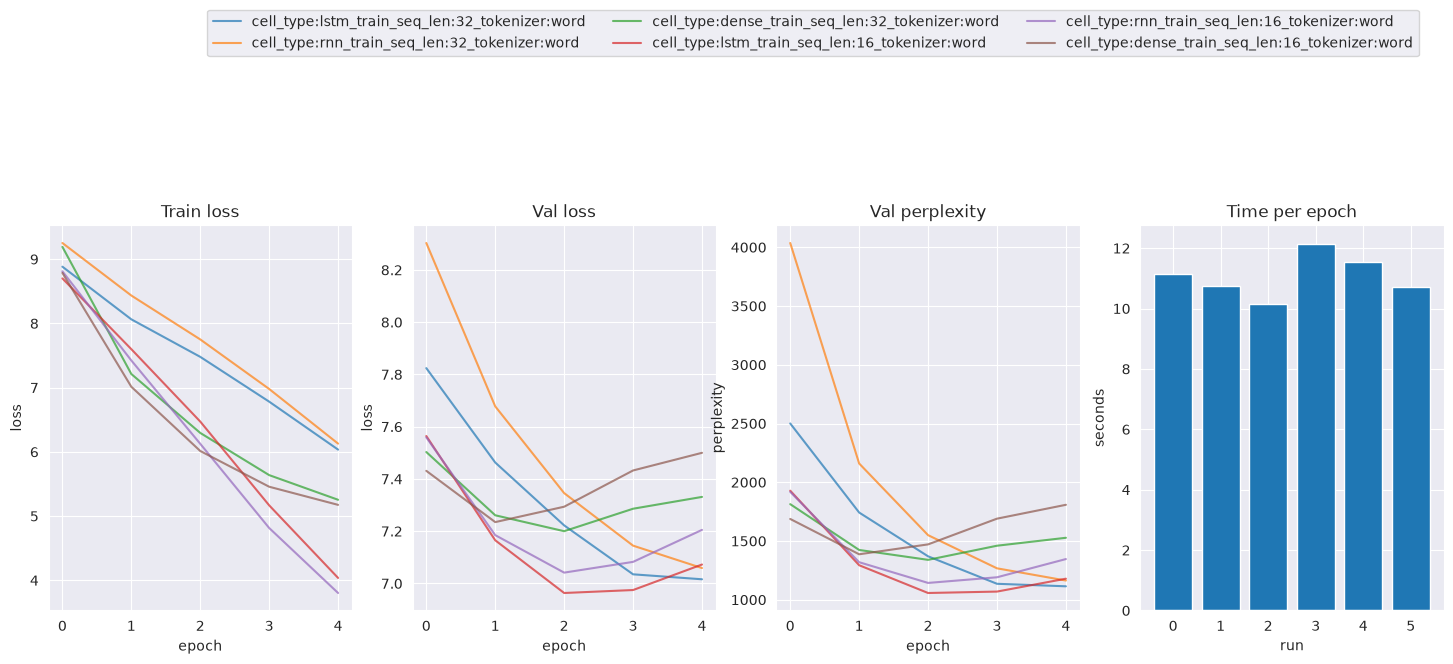

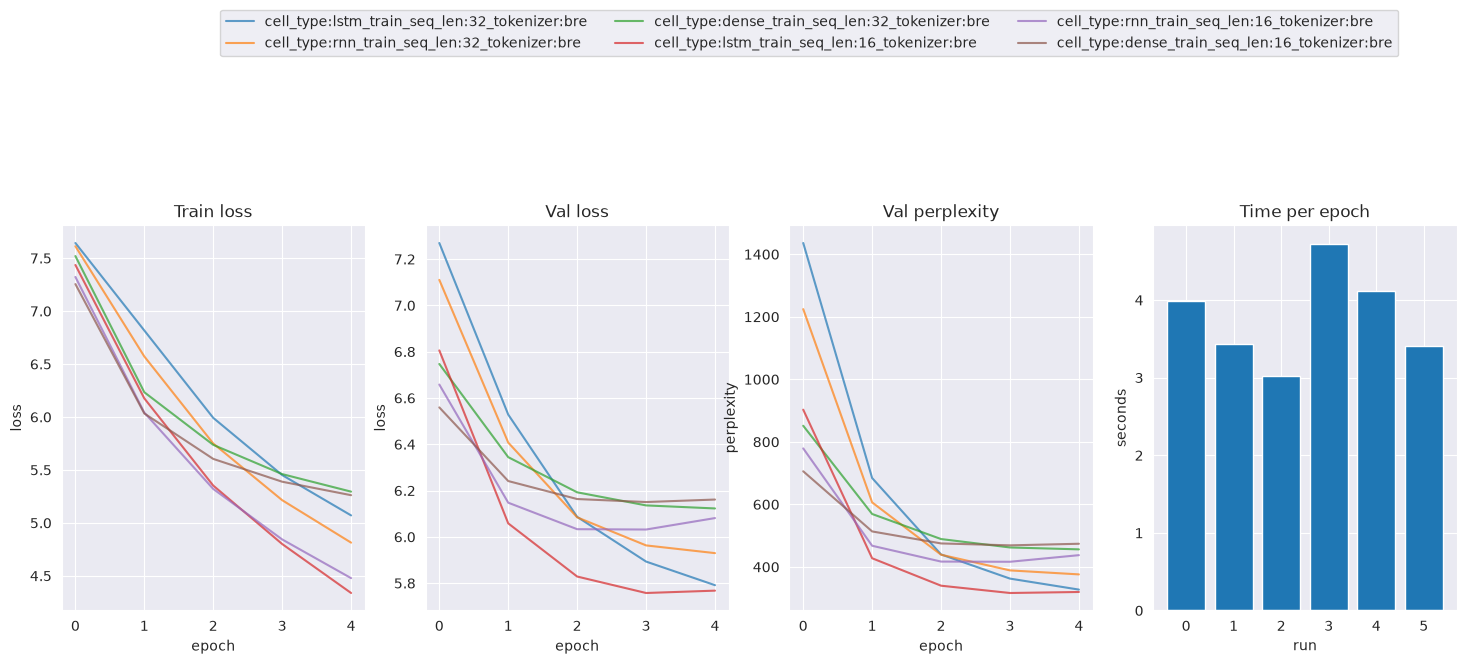

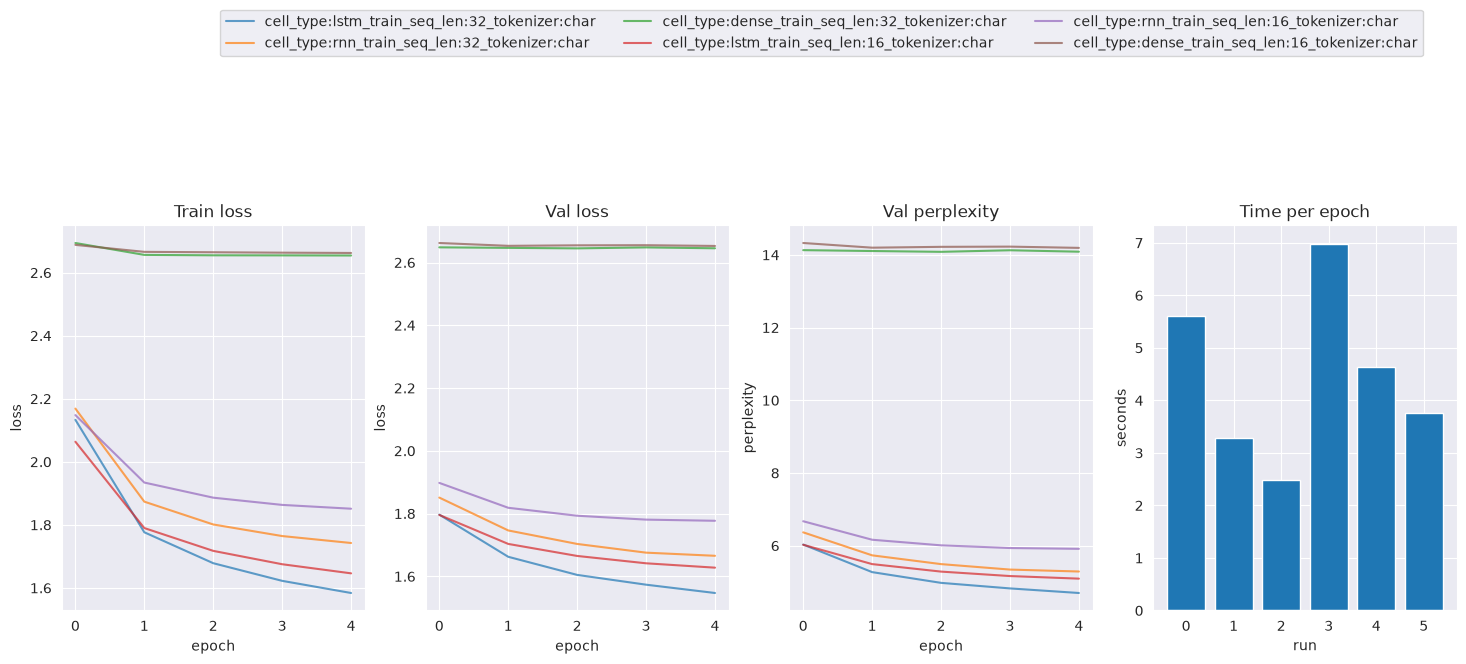

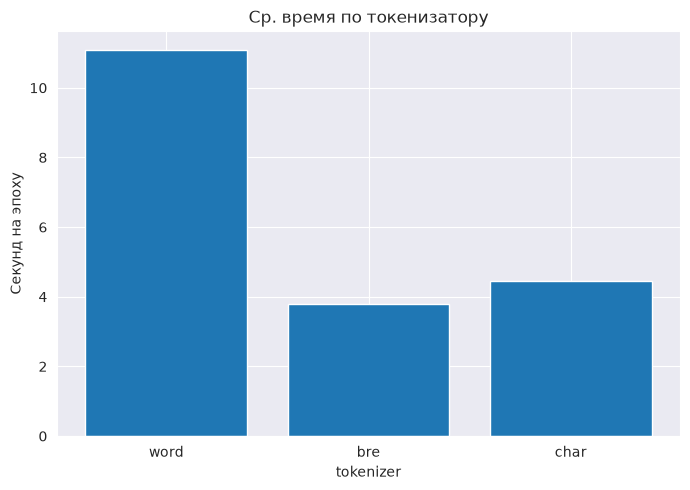

In [31]:


client = MlflowClient()

experiments = client.search_experiments()
exp_ids = [e.experiment_id for e in experiments]

tokenizer_times = {}

for tokenizer_name in ['word', 'bre', 'char']:
    runs = client.search_runs(
        experiment_ids=exp_ids,
        filter_string=f"params.tokenizer = '{tokenizer_name}'"
    )

    cmap = plt.get_cmap("tab10")
    color_map = {run.info.run_id: cmap(i) for i, run in enumerate(runs)}

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    print_params = ['cell_type', 'tokenizer', 'train_seq_len']

    times_per_epoch = []

    for run in runs:
        run_id = run.info.run_id
        run_info = "_".join(f"{key}:{value}" for key, value in run.data.params.items() if key in print_params)
        color = color_map[run_id]

        for ax, metric_name in zip(axes[:3], ["train_loss", "val_loss", "val_perplexity"]):
            history = client.get_metric_history(run_id, metric_name)

            if not history:
                continue

            steps = [m.step for m in history]
            values = [m.value for m in history]

            ax.plot(steps, values, color=color, alpha=0.7, label=run_info)

        if run.info.start_time is not None and run.info.end_time is not None:
            history = client.get_metric_history(run_id, "train_loss")
            n_epochs = len(history)

            if n_epochs > 0:
                duration_sec = (run.info.end_time - run.info.start_time) / 1000
                times_per_epoch.append(duration_sec / n_epochs)

    axes[3].bar(range(len(times_per_epoch)), times_per_epoch)
    axes[3].set_xlabel("run")
    axes[3].set_ylabel("seconds")
    axes[3].set_title("Time per epoch")
    if times_per_epoch:
        tokenizer_times[tokenizer_name] = sum(times_per_epoch) / len(times_per_epoch)

    for ax, title, ylabel in zip(
            axes[:3],
            ["Train loss", "Val loss", "Val perplexity"],
            ["loss", "loss", "perplexity"]
    ):
        ax.set_xlabel("epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(title)

        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axes[0].legend(unique.values(), unique.keys(), loc="center left", bbox_to_anchor=(0.5, 1.5),
                       ncol=len(unique) // 2)
    plt.show()

plt.figure(figsize=(7, 5))
plt.bar(tokenizer_times.keys(), tokenizer_times.values())
plt.xlabel("tokenizer")
plt.ylabel("Секунд на эпоху")
plt.title("Ср. время по токенизатору")
plt.tight_layout()
plt.show()

### Генерация текста

Во время обучения модель учится по предыдущим токенам предсказывать следующий. При генерации мы используем это умение: сначала даем модели исходный `prompt`, а затем последовательно добавляем предсказанные токены.

Например, если `prompt`:

```text
я люблю
```

модель может предсказать:

```text
читать
```

После этого получаем уже:

```text
я люблю читать
```

и модель снова должна предсказать следующий токен.

В `generate` этот процесс выполняется в цикле:

1. `prompt` преобразуется в идентификаторы токенов с помощью `tokenizer.encode()`.
2. Токены передаются в модель.
3. Модель возвращает `logits` для всех токенов словаря.
4. `torch.argmax()` выбирает токен с максимальным значением `logits`.
5. Выбранный токен добавляется к результату.
6. Новый токен снова передается в модель.

Для `RNN` и `LSTM` между шагами сохраняется `hidden`. Это скрытое состояние содержит информацию о предыдущем контексте, поэтому после первого шага достаточно передавать в модель только новый токен:

```text
prompt → модель → следующий токен
                 ↓
           hidden сохраняется
                 ↓
новый токен → модель → следующий токен
```

В `DenseLM` `hidden` не используется, поэтому модель не сохраняет контекст между отдельными шагами генерации.

Генерация продолжается максимум `max_new_tokens` раз. `torch.no_grad()` используется потому, что здесь модель не обучается, а только делает предсказания.


In [33]:
class LanguageModelGenerator:
    """Генератор текста на основе обученной языковой модели"""

    def __init__(self, model):
        self.model = model
        self.tokenizer = model.tokenizer

    @torch.no_grad()
    def generate(self, prompt, max_new_tokens=50):
        """Генерирует продолжение текста на основе заданного контекста

        Args:
            prompt: Исходный текст, который используется как контекст/начало генерации
            max_new_tokens: Максимальное количество новых токенов

        Returns:
            Исходный prompt с добавленным сгенерированным продолжением
        """
        self.model.eval()
        device = next(self.model.parameters()).device
        tokens = self.tokenizer.encode(prompt)
        x = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

        hidden = None

        for _ in range(max_new_tokens):
            logits, hidden = self.model(x, hidden)
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(
                next_token_logits,
                dim=-1,
                keepdim=True
            )
            x = next_token
            tokens.append(next_token.item())

        return self.tokenizer.decode(tokens)

### Оценка генерации

После обучения модели полезно проверить не только численные метрики, но и сам результат генерации. Для текста это особенно важно: модель может иметь приемлемые значения `loss` и `perplexity`, но при этом генерировать несвязный или бессмысленный текст.

Функция `load_model` загружает из MLflow все необходимые данные для восстановления эксперимента:

* параметры модели;
* веса обученной модели;
* сохраненный токенизатор.

После загрузки модель переводится в режим `eval` и готова к генерации.

`eval_model` проверяет модель на примерах из корпуса. Для каждого текста:

1. первые `prompt_len` слов используются как исходный `prompt`;
2. следующие `generation_len` слов берутся как эталонный текст;
3. модель генерирует продолжение такой же длины;
4. сохраняются `prompt`, эталонное продолжение и результат генерации.

Получается возможность сравнить:

```
Prompt:
...

Reference:
...

Generated:
...
```

Здесь полезно оценивать результат не только по метрикам, но и глазам. При сравнении моделей можно смотреть, насколько генерация:

* похожа на связный русский текст;
* сохраняет тему исходного текста;
* продолжает мысль из `prompt`;
* содержит повторения или бессмысленные фразы;
* использует `<unk>` и другие специальные токены.
### Метрики качества генерации

Потенциально для оценки качества сгенерированного текста можно использовать специальные метрики, например BLEU, ROUGE и другие методы сравнения текстов.

Однако на данном этапе наши модели пока слишком простые и слабые, поэтому такие метрики не дадут нам особенно полезной информации. Сейчас важнее понять сам процесс генерации и научиться оценивать результат по примерам.

Более продвинутые методы оценки качества текста мы рассмотрим в следующих практических работах.


In [62]:
def load_model(run_id, model_factory, device) -> BaseLanguageModel:
    """Загружает обученную модель и ее токенизатор из MLflow

    Args:
        run_id: Идентификатор запуска эксперимента в MLflow
        model_factory: Фабрика для создания модели нужного типа
        device: Устройство, на которое загружается модель

    Returns:
        Загруженная и готовая к использованию языковая модель
    """
    run = mlflow.get_run(run_id)
    run_name = run.info.run_name
    client = mlflow.MlflowClient()
    cell_type = run.data.params["cell_type"]
    emb_dim = int(run.data.params["emb_dim"])
    hidden_dim = int(run.data.params['hidden_dim'])
    artifacts = client.list_artifacts(run_id)
    print(artifacts)
    if not artifacts:
        raise RuntimeError(f"No artifacts found for run {run_id}")
    ckpt_artifact = f"{run_name}.pt"
    tokenizer_artifact = f"{run_name}_tokenizer.pkl"

    if ckpt_artifact is None:
        raise RuntimeError(f"No .pt checkpoint found in MLflow run {run_id}")
    if tokenizer_artifact is None:
        raise RuntimeError(f"No .pt tokenizer found in MLflow run {run_id}")

    ckpt_path = client.download_artifacts(run_id, ckpt_artifact)
    tokenizer_path = client.download_artifacts(run_id, tokenizer_artifact)
    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)
    model = model_factory(cell_type, tokenizer, emb_dim=emb_dim, hidden_dim=hidden_dim)

    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    try:
        os.remove(ckpt_path)
        os.remove(tokenizer_path)
    except OSError:
        pass
    return model


def eval_model(run_id, docs, prompt_len, generation_len, model_factory, generator_fn=LanguageModelGenerator,
               device="cuda"):
    """Оценивает качество генерации модели на примерах из корпуса

    Args:
        run_id: Идентификатор запуска эксперимента в MLflow
        docs: Набор документов для проверки генерации
        prompt_len: Количество слов в исходном prompt
        generation_len: Количество токенов в эталонном продолжении
        model_factory: Фабрика для создания модели
        generator_fn: Класс или функция для генерации текста
        device: Устройство, на котором выполняется генерация

    Returns:
        Список результатов с prompt, эталонным и сгенерированным текстом
    """
    model = load_model(run_id, model_factory, device)
    model = generator_fn(model)

    results = []
    for doc in docs:
        if len(doc.split()) < prompt_len + generation_len:
            continue
        prompt = ' '.join(doc.split()[:prompt_len])

        reference = ' '.join(doc.split()[prompt_len: prompt_len + generation_len])
        generation_token_count = model.tokenizer.get_token_count(reference)
        generated = model.generate(prompt, max_new_tokens=generation_token_count)
        generated_text = " ".join(generated.split()[:])
        reference_text = reference
        results.append(
            {
                'generated_text': generated_text,
                'reference_text': reference_text,
                'promt': prompt
            }
        )

    return results


### Проверка лучшей модели

Давайте найдем лучшую модель среди экспериментов с `CharTokenizer`. Для этого выберем запуск с минимальным `test_ppl`, загрузим соответствующую модель и посмотрим, как она генерирует текст на примерах из тестовой выборки.

Результаты генерации сохраним в MLflow вместе с исходным `prompt` и эталонным продолжением. Это позволит сравнить качество генерации не только по численным метрикам, но и визуально.


In [72]:
experiments = client.search_experiments()
exp_ids = [e.experiment_id for e in experiments]
runs = client.search_runs(
    experiment_ids=exp_ids,
    filter_string="params.tokenizer = 'bre'",

)
runs = [r for r in runs if "test_ppl" in r.data.metrics]

best = min(runs, key=lambda r: r.data.metrics["test_ppl"])
print(best.data)
generated_texts = eval_model(best.info.run_id, test_docs[0:1], 100, 100, model_factory)

with mlflow.start_run(run_id=best.info.run_id):
    for idx, generated_text in enumerate(generated_texts):
        result = f"""PROMPT:
                            {generated_text['promt']}
REF:
{generated_text['reference_text']}
                        
GENERATED:
{generated_text['generated_text']}"""
        mlflow.log_text(result, f"generation_{idx}.txt")

<RunData: metrics={'best_val_loss': 5.757568330600344,
 'best_val_ppl': 316.57758018023634,
 'lr': 0.002,
 'test_loss': 5.841879367828369,
 'test_ppl': 344.4260359967256,
 'train_loss': 4.337946192145868,
 'val_loss': 5.767728287598183,
 'val_perplexity': 319.8103895747887}, params={'cell_type': 'lstm',
 'emb_dim': '256',
 'epochs': '5',
 'hidden_dim': '512',
 'n_parameters': '7728960',
 'n_train': '500',
 'num_layers': '1',
 'tokenizer': 'bre',
 'train_seq_len': '16'}, tags={'mlflow.runName': 'fun-zebra-781',
 'mlflow.source.name': '01-lstm.ipynb',
 'mlflow.source.type': 'NOTEBOOK',
 'mlflow.user': 'ikar'}>
[<FileInfo: file_size=30919135, is_dir=False, path='fun-zebra-781.pt'>, <FileInfo: file_size=484653, is_dir=False, path='fun-zebra-781_tokenizer.pkl'>, <FileInfo: file_size=4126, is_dir=False, path='generation.txt'>]


[{'generated_text': 'На российских доро гах произо шли несколько тяже лых аварий из - за вые зда на встре чку . В Ка лу ж ской области в среду вечером тяже лые травмы в результате ДТП получил лет чик - космо нав т Виктор А фана сь ев сообщает РИА Новости . Ава рия произошла около 21 часа в среду на трас се Укра ина в Ка лу ж ской области . По предвари тельной информации на 23 4 км авто дороги в Вол гу которой управ лял 61 - летний А фана сь ев вре за лся автомобиль D a ew oo M at i z вые ха вший на встре чную поло су для об го на . В результате аварии лет чик - космо нав т Ге рой Совет ского Союза Виктор А фана сь ев получил тяже лые травмы пере лом бе дра го ле ни со тря сение моз га . Также ранения получили водитель и пассажи ры автомобиля D a ew oo в том числе пяти летний ре бе нок . Все они достав лены в боль ницу . В итоге в России и в этом сезоне - то из - за того что в этом году не было . В итоге в России и в отношении женщин и не было . В итоге в России и в отношении женщин и н

### Просмотр результата

Мы сохранили результаты генерации в MLflow. Теперь посмотрим, какие артефакты были сохранены в выбранном запуске, и откроем один из файлов с результатом генерации.

Так мы можем вернуться к результатам эксперимента даже после завершения обучения и сравнить `PROMPT`, эталонное продолжение и текст, сгенерированный моделью.


In [76]:
artifacts = client.list_artifacts(best.info.run_id)
for artifact in artifacts:
    print(artifact.path)
text = client.download_artifacts(
    best.info.run_id,
    "generation_0.txt"
)

with open(text, encoding="utf-8") as f:
    print(f.read())

fun-zebra-781.pt
fun-zebra-781_tokenizer.pkl
generation.txt
generation_0.txt


PROMPT:
                            На российских дорогах произошли несколько тяжелых аварий из-за выезда на встречку. В Калужской области в среду вечером тяжелые травмы в результате ДТП получил летчик-космонавт Виктор Афанасьев сообщает РИА Новости. Авария произошла около 21 часа в среду на трассе Украина в Калужской области. По предварительной информации на 234 км автодороги в Волгу которой управлял 61-летний Афанасьев врезался автомобиль Daewoo Matiz выехавший на встречную полосу для обгона. В результате аварии летчик-космонавт Герой Советского Союза Виктор Афанасьев получил тяжелые травмы перелом бедра голени сотрясение мозга. Также ранения получили водитель и пассажиры автомобиля Daewoo в том числе пятилетний ребенок. Все они доставлены в больницу
REF:
города Сухиничи. Летчик-космонавт полковник Виктор Афанасьев родился в 1948 году в Брянске в 1970 году окончил Качинское высшее военное авиационное командное училище летчиков имени А. Ф. Мясникова работал летчиком-испытателем НИИ ВВ

## Самостоятельная работа

### Задание 3. Влияние объема данных

Повторите серию экспериментов, увеличив объем обучающих данных и количество эпох.

Рекомендуемые ориентиры:

* `RAW_ARTICLES_LIMIT`: возьмите как минимум в 5–10 раз больше статей, чем в базовом прогоне (например, 20000–30000 вместо 500–1000);
* `EPOCHS`: увеличьте до значения, при котором `val_loss` выходит на плато (обычно 10-20 эпох вместо 5) - ориентируйтесь на кривые, а не берите число произвольно;
* если ресурсов не хватает на полную матрицу «3 токенизатора × несколько `seq_len` × 3 архитектуры», зафиксируйте один `seq_len` (тот, что показал себя лучше в ключевом эксперименте) и варьируйте только токенизатор и архитектуру - это не считается упрощением задания, это нормальная практика при ограниченном бюджете, просто зафиксируйте выбор явно.

Важно про время: перед тем как запускать полную серию, оцените время на одном прогоне (одна эпоха, одна конфигурация) и умножьте на количество запланированных комбинаций. Если суммарное время превышает разумные рамки для вашего окружения (Colab-сессия, доступная GPU-квота и т.д.), уменьшите либо число статей, либо число эпох, либо число сравниваемых конфигураций - и опишите это решение в выводе.

Постройте три bar-графика:

* `test_ppl` для разных токенизаторов (при фиксированной архитектуре и объеме данных);
* среднее время обучения одной эпохи для разных токенизаторов;
* `test_ppl` для `Dense`, `RNN` и `LSTM` (при фиксированном токенизаторе).

На каждом графике сравните новый результат (больше данных/эпох) со значением из базового эксперимента - покажите пару столбцов «было / стало», а не только новые цифры.

**Вывод должен явно отвечать на вопросы:**

1. Как увеличение объема данных повлияло на `test_ppl` - одинаково ли для всех токенизаторов и архитектур, или есть токенизатор/архитектура, которые выигрывают больше остальных?
2. Оправдан ли прирост качества с точки зрения затраченного времени обучения ?
3. Есть ли признаки переобучения (расхождение `train_loss` и `val_loss`) при увеличении числа эпох, и как вы бы на это отреагировали (early stopping, dropout, regularization)?

### Задание 4. Сравнение генерации

Сравните генерацию текста у лучших моделей (по `test_ppl`) по трем осям:

1. разные токенизаторы (при одинаковой архитектуре и объеме данных);
2. разное количество обучающих статей ;
3. разные архитектуры внутри одного токенизатора.


```text
PROMPT:
...

REFERENCE:
...

GENERATED:
...
```

Сравните результаты визуально и сделайте вывод о том, как токенизация, архитектура и количество обучающих данных влияют на качество сгенерированного текста.

### Перенос результатов MLflow на локальный компьютер

Если эксперименты выполнялись в Google Colab, результаты MLflow можно сохранить в архив и перенести на локальный компьютер. Это позволяет продолжить работу с экспериментами без повторного обучения моделей.

#### 1. Сохраните результаты MLflow в архиве

В Colab убедитесь, что рядом находятся база `mlflow.db` и папка с артефактами `mlruns`:

```python
!ls -lh mlflow.db
!ls -lh mlruns
```

Создайте архив:

```python
!zip -r mlflow_results.zip mlflow.db mlruns
```

Скачайте его на компьютер:

```python
from google.colab import files

files.download("mlflow_results.zip")
```

После выполнения появится файл `mlflow_results.zip`, который нужно сохранить на локальный компьютер.

---

#### 2. Распакуйте архив

Создайте отдельную папку для результатов, например:

```text
mlflow_results/
├── mlflow.db
└── mlruns/
```

Распакуйте туда скачанный архив.

В Windows это можно сделать через проводник, а в Linux/macOS:

```bash
unzip mlflow_results.zip -d mlflow_results
```

Проверьте структуру:

```bash
ls mlflow_results
```

Должны находиться:

```text
mlflow.db
mlruns/
```

> Если при распаковке получилась дополнительная вложенная папка, например `mlflow_results/mlflow_results/mlflow.db`, переместите файлы так, чтобы `mlflow.db` и `mlruns` находились на одном уровне.

---

#### 3. Установите MLflow

Если MLflow еще не установлен:

```bash
pip install mlflow
```

Проверить установку можно командой:

```bash
mlflow --version
```

---

#### 4. Запустите MLflow локально

Перейдите в папку, где находятся `mlflow.db` и `mlruns`:

```bash
cd mlflow_results
```

Запустите интерфейс MLflow:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

После запуска в терминале появится адрес локального интерфейса, например:

```text
http://127.0.0.1:5000
```

Откройте этот адрес в браузере.

---

#### 5. Проверьте результаты экспериментов

В интерфейсе MLflow должны быть доступны ранее выполненные эксперименты и их запуски.

Проверьте, что сохранились:

* параметры экспериментов;
* `train_loss`;
* `val_loss`;
* `val_perplexity`;
* `test_loss`;
* `test_ppl`;
* время запуска;
* сохраненные модели `.pt`;
* токенизаторы;
* файлы с результатами генерации.

Особенно важно проверить **Artifacts** у выбранного запуска. Там должны находиться сохраненные файлы, например:

```text
<run_name>.pt
<run_name>_tokenizer.pkl
generation_0.txt
generation_1.txt
...
```

Таким образом, нужно убедиться не только в том, что MLflow открывается, но и в том, что **результаты экспериментов и сохраненные артефакты доступны после переноса**.

#### 6. Что должно получиться

В результате у вас должна быть локальная копия результатов экспериментов:

```text
Локальный компьютер
│
└── mlflow_results/
    ├── mlflow.db
    └── mlruns/
        └── ...
```

При запуске:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

MLflow должен показать эксперименты, которые были выполнены ранее в Colab.

**Важно:** одной базы `mlflow.db` недостаточно. Она хранит информацию об экспериментах, параметрах и метриках, а сами сохраненные модели и другие файлы находятся в хранилище артефактов. Поэтому при переносе нужно копировать и `mlflow.db`, и папку `mlruns` (если именно она используется как artifact storage).
